# 销售数据分析可视化看板

**数据来源**：《Excel数据可视化——从图表到数据大屏》第四章 销售看板素材（2021 年全年，8564 条订单明细 + 成本明细）

**分析内容**：
- 核心 KPI：销售额 / 利润额 / 订单量 / 利润率
- 月度销售与利润趋势
- 区域、产品类别、快递公司维度分析
- TOP10 产品、月度成本构成

In [1]:
# 通用设置：路径、中文字体
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 中文字体（Windows 自带微软雅黑）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

# 定位项目 data 目录（notebook 位于 notebooks/ 下）
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA = ROOT / 'data'

# Excel 风格配色
COLORS = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5', '#70AD47']
print('数据目录:', DATA)


数据目录: C:\agent开发项目\大数据分析及数据可视化\data


## 1. 数据加载

In [2]:
sales = pd.read_excel(DATA / '销售数据.xlsx', sheet_name='销售明细')
cost = pd.read_excel(DATA / '销售数据.xlsx', sheet_name='成本明细')

# 月份按 1-12 排序
month_order = [f'{i}月' for i in range(1, 13)]

print('订单明细:', sales.shape, '| 成本明细:', cost.shape)
sales.head(3)

订单明细: (8564, 10) | 成本明细: (48, 3)


,订单日期,订单单号,区域,快递公司,订单额,产品单价,利润额,产品类别,产品名称,月份_销售
0,2021-10-13,10021265709,华北,顺丰,261.54,38.94,-213.25,办公用品,Crate-A-Files™,10月
1,2021-02-20,10021250753,华南,顺丰,6.93,2.08,-4.64,办公用品,Letter Slitter,2月
2,2021-07-15,10021257699,华南,顺丰,2808.08,107.53,1054.82,家具产品,Document Clip Frames,7月


## 2. 核心指标（KPI）

In [3]:
total_sales = sales['订单额'].sum()
total_profit = sales['利润额'].sum()
orders = len(sales)
profit_rate = total_profit / total_sales

print(f'全年销售额 : {total_sales/10000:,.2f} 万元')
print(f'全年利润额 : {total_profit/10000:,.2f} 万元')
print(f'订单行数   : {orders:,} 单')
print(f'整体利润率 : {profit_rate:.2%}')
print(f'总成本     : {cost["成本"].sum()/10000:,.2f} 万元')

全年销售额 : 1,515.35 万元
全年利润额 : 154.91 万元
订单行数   : 8,564 单
整体利润率 : 10.22%
总成本     : 1.25 万元


## 3. 销售看板（九图联动）

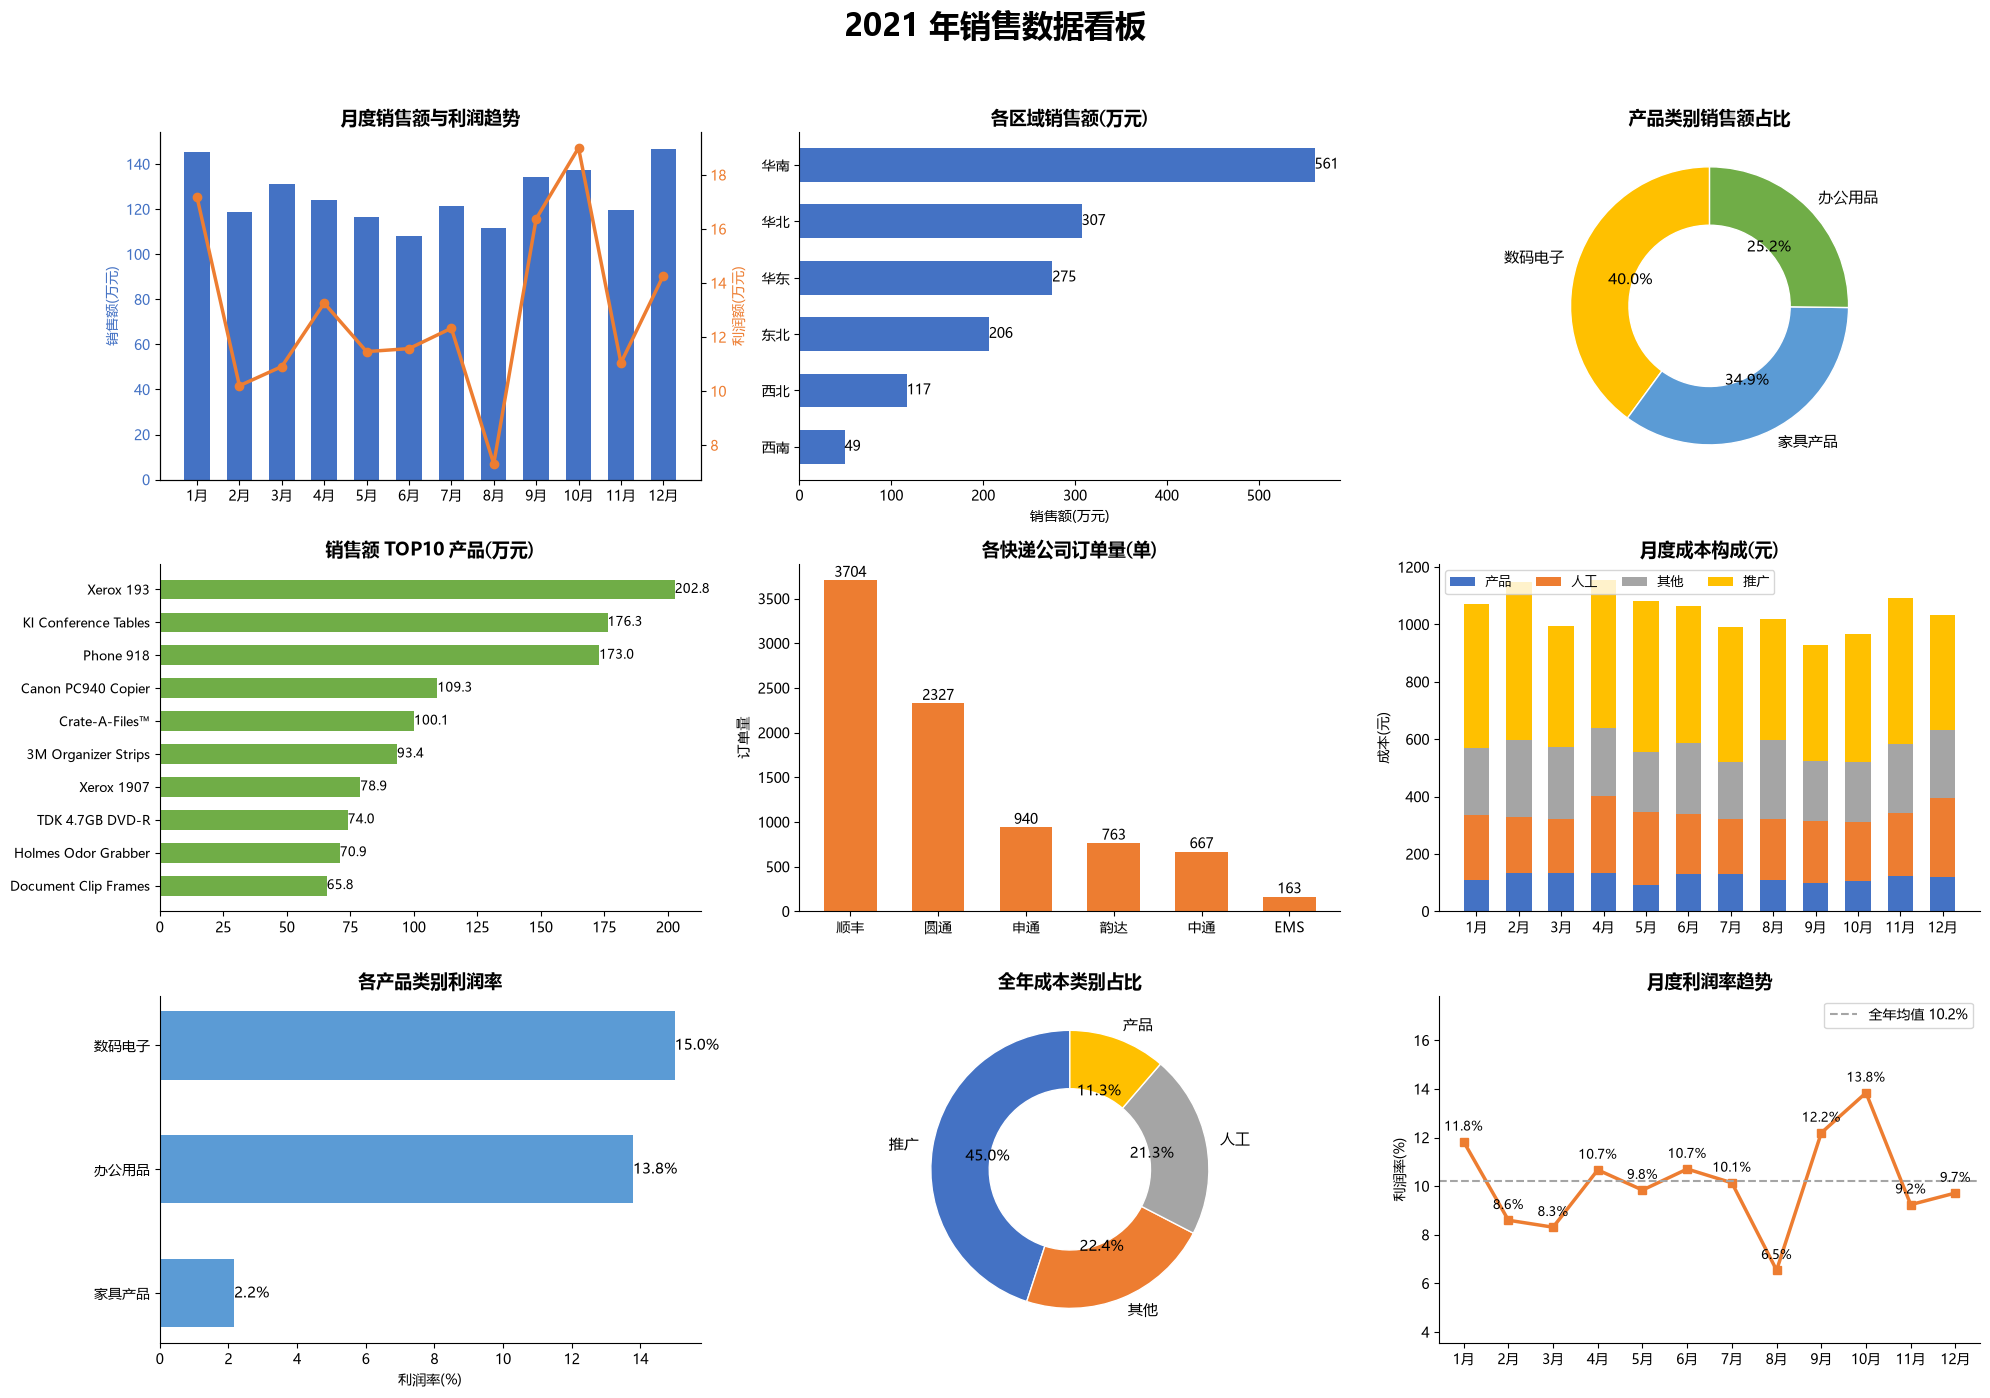

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle('2021 年销售数据看板', fontsize=22, fontweight='bold', y=0.995)

# (1) 月度销售额(柱) + 利润额(线) 双轴
ax = axes[0, 0]
m_sales = sales.groupby('月份_销售')['订单额'].sum().reindex(month_order) / 10000
m_profit = sales.groupby('月份_销售')['利润额'].sum().reindex(month_order) / 10000
bars = ax.bar(m_sales.index, m_sales.values, color=COLORS[0], width=0.6, label='销售额(万)')
ax.set_ylabel('销售额(万元)', color=COLORS[0])
ax.tick_params(axis='y', labelcolor=COLORS[0])
ax2 = ax.twinx()
ax2.plot(m_profit.index, m_profit.values, color=COLORS[1], marker='o', lw=2.5, label='利润额(万)')
ax2.set_ylabel('利润额(万元)', color=COLORS[1])
ax2.tick_params(axis='y', labelcolor=COLORS[1])
ax.set_title('月度销售额与利润趋势', fontsize=13, fontweight='bold')
ax.spines[['top']].set_visible(False); ax2.spines[['top']].set_visible(False)

# (2) 区域销售额 条形图
ax = axes[0, 1]
g = sales.groupby('区域')['订单额'].sum().sort_values() / 10000
bars = ax.barh(g.index, g.values, color=COLORS[0], height=0.6)
ax.bar_label(bars, fmt='%.0f', fontsize=10)
ax.set_title('各区域销售额(万元)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('销售额(万元)')

# (3) 产品类别销售额 圆环图
ax = axes[0, 2]
g = sales.groupby('产品类别')['订单额'].sum().sort_values(ascending=False)
ax.pie(g.values, labels=g.index, autopct='%1.1f%%', colors=COLORS[3:], startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='w'), textprops={'fontsize': 11})
ax.set_title('产品类别销售额占比', fontsize=13, fontweight='bold')

# (4) TOP10 产品
ax = axes[1, 0]
g = sales.groupby('产品名称')['订单额'].sum().nlargest(10).sort_values() / 10000
bars = ax.barh(g.index, g.values, color=COLORS[5], height=0.6)
ax.bar_label(bars, fmt='%.1f', fontsize=9)
ax.set_title('销售额 TOP10 产品(万元)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)

# (5) 快递公司订单量
ax = axes[1, 1]
g = sales['快递公司'].value_counts()
bars = ax.bar(g.index, g.values, color=COLORS[1], width=0.6)
ax.bar_label(bars, fontsize=10)
ax.set_title('各快递公司订单量(单)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('订单量')

# (6) 月度成本构成 堆叠柱
ax = axes[1, 2]
pv = cost.pivot_table(index='月份_成本', columns='类别', values='成本', aggfunc='sum').reindex(month_order)
bottom = np.zeros(len(pv))
for i, col in enumerate(pv.columns):
    ax.bar(pv.index, pv[col].values, bottom=bottom, label=col, color=COLORS[i], width=0.6)
    bottom += pv[col].values
ax.set_title('月度成本构成(元)', fontsize=13, fontweight='bold')
ax.legend(ncol=4, fontsize=9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('成本(元)')

# (7) 各产品类别利润率
ax = axes[2, 0]
g = sales.groupby('产品类别').apply(lambda d: d['利润额'].sum() / d['订单额'].sum(), include_groups=False)
g = g.sort_values(ascending=True)
bars = ax.barh(g.index, g.values * 100, color=COLORS[4], height=0.55)
ax.bar_label(bars, fmt='%.1f%%', fontsize=11)
ax.set_title('各产品类别利润率', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('利润率(%)')

# (8) 成本类别占比 圆环图
ax = axes[2, 1]
g = cost.groupby('类别')['成本'].sum().sort_values(ascending=False)
ax.pie(g.values, labels=g.index, autopct='%1.1f%%', colors=COLORS[:4], startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='w'), textprops={'fontsize': 11})
ax.set_title('全年成本类别占比', fontsize=13, fontweight='bold')

# (9) 月度利润率趋势
ax = axes[2, 2]
rate = (m_profit / m_sales * 100)
ax.plot(rate.index, rate.values, color=COLORS[1], marker='s', lw=2.5)
for x, y in zip(rate.index, rate.values):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.axhline(profit_rate*100, color=COLORS[2], ls='--', lw=1.5, label=f'全年均值 {profit_rate:.1%}')
ax.set_title('月度利润率趋势', fontsize=13, fontweight='bold')
ax.set_ylabel('利润率(%)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(rate.min() - 3, rate.max() + 4)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 4. 分析结论与建议

In [5]:
# 结论数据支撑
best_month = m_sales.idxmax()
worst_month = m_sales.idxmin()
best_region = sales.groupby('区域')['订单额'].sum().idxmax()
cat_profit = sales.groupby('产品类别').apply(
    lambda d: d['利润额'].sum() / d['订单额'].sum(), include_groups=False).sort_values(ascending=False)
loss_orders = (sales['利润额'] < 0).sum()
loss_amt = sales.loc[sales['利润额'] < 0, '利润额'].sum() / 10000

print(f'销售峰值月 : {best_month}（{m_sales.max():.0f} 万元），低谷月 : {worst_month}（{m_sales.min():.0f} 万元）')
print(f'最强区域   : {best_region}')
print(f'亏损订单   : {loss_orders} 单（占 {loss_orders/orders:.1%}），亏损额合计 {loss_amt:.1f} 万元')
print('各类别利润率:')
for k, v in cat_profit.items():
    print(f'  {k}: {v:.2%}')

销售峰值月 : 12月（147 万元），低谷月 : 6月（108 万元）
最强区域   : 华南
亏损订单   : 4349 单（占 50.8%），亏损额合计 -111.1 万元
各类别利润率:
  数码电子: 15.00%
  办公用品: 13.79%
  家具产品: 2.17%


### 主要结论

1. **全年销售 1515 万元、利润 155 万元**，整体利润率约 10.2%；12 月为销售峰值（147 万）、6 月为低谷（108 万），需结合波动做备货与营销节奏安排。
2. **区域集中**：华南区域贡献最大，西南、西北偏弱，可评估弱势区域是物流覆盖不足还是需求不足。
3. **产品结构分化明显**：数码电子（15.0%）和办公用品（13.8%）利润率健康，**家具产品利润率仅 2.17%**，是拉低整体利润的关键品类，需重点优化其定价、折扣与成本结构。
4. **亏损订单面广**：4349 单（50.8%）利润为负，利润中位数为 -1.6 元；亏损额合计 -111 万元，被盈利单的 +266 万元对冲。其中办公用品亏损单最多（2503 单），建议专项筛查折扣规则与小额订单的成本倒挂。
5. **物流**：顺丰占比超四成（3704 单），服务与成本需平衡；EMS 仅 163 单，可考虑淘汰或替换。
6. **成本**：推广/人工/产品/其他四类成本可逐月追踪，建议将成本与销售额联动计算投产比（ROI）。